In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df=pd.read_csv("Dataset\Application_Data.csv")

In [26]:
df.shape

(25128, 21)

In [27]:
df.columns

Index(['Applicant_ID', 'Applicant_Gender', 'Owned_Car', 'Owned_Realty',
       'Total_Children', 'Total_Income', 'Income_Type', 'Education_Type',
       'Family_Status', 'Housing_Type', 'Owned_Mobile_Phone',
       'Owned_Work_Phone', 'Owned_Phone', 'Owned_Email', 'Job_Title',
       'Total_Family_Members', 'Applicant_Age', 'Years_of_Working',
       'Total_Bad_Debt', 'Total_Good_Debt', 'Status'],
      dtype='object')

In [28]:
df.dtypes

Applicant_ID             int64
Applicant_Gender        object
Owned_Car                int64
Owned_Realty             int64
Total_Children           int64
Total_Income             int64
Income_Type             object
Education_Type          object
Family_Status           object
Housing_Type            object
Owned_Mobile_Phone       int64
Owned_Work_Phone         int64
Owned_Phone              int64
Owned_Email              int64
Job_Title               object
Total_Family_Members     int64
Applicant_Age            int64
Years_of_Working         int64
Total_Bad_Debt           int64
Total_Good_Debt          int64
Status                   int64
dtype: object

In [29]:
missing=df.isnull().sum()

In [30]:
missing_pct = (missing / len(df) * 100).round(2)
missing_pct

Applicant_ID            0.0
Applicant_Gender        0.0
Owned_Car               0.0
Owned_Realty            0.0
Total_Children          0.0
Total_Income            0.0
Income_Type             0.0
Education_Type          0.0
Family_Status           0.0
Housing_Type            0.0
Owned_Mobile_Phone      0.0
Owned_Work_Phone        0.0
Owned_Phone             0.0
Owned_Email             0.0
Job_Title               0.0
Total_Family_Members    0.0
Applicant_Age           0.0
Years_of_Working        0.0
Total_Bad_Debt          0.0
Total_Good_Debt         0.0
Status                  0.0
dtype: float64

In [31]:
# Make copy
df_clean = df.copy()

# 1) Drop columns with >50% missing
threshold = 0.5 * len(df_clean)
cols_to_drop = [c for c in df_clean.columns if df_clean[c].isnull().sum() > threshold]
print("drop ( >50% missing ):", cols_to_drop)
df_clean.drop(columns=cols_to_drop, inplace=True)

# 2) For imputation: separate numeric vs categorical
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
obj_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()

# Convert object columns that are numeric-like
for c in obj_cols.copy():
    coerced = pd.to_numeric(df_clean[c], errors='coerce')
    if coerced.notna().sum() / len(df_clean) > 0.8:
        df_clean[c] = coerced
        num_cols.append(c)
        obj_cols.remove(c)

# Impute numeric with median
for c in num_cols:
    med = df_clean[c].median()
    df_clean[c].fillna(med, inplace=True)

# Impute categorical with mode; if no mode -> 'Unknown'
for c in obj_cols:
    if df_clean[c].dropna().shape[0] == 0:
        df_clean[c] = df_clean[c].fillna('Unknown')
    else:
        mode = df_clean[c].mode(dropna=True)
        if not mode.empty:
            df_clean[c].fillna(mode[0], inplace=True)
        else:
            df_clean[c].fillna('Unknown', inplace=True)


drop ( >50% missing ): []


In [43]:
df_clean.dtypes

Applicant_ID              int64
Applicant_Gender         object
Owned_Car                 int32
Owned_Realty              int32
Total_Children          float64
Total_Income              int64
Income_Type              object
Education_Type           object
Family_Status            object
Housing_Type             object
Owned_Mobile_Phone        int32
Owned_Work_Phone          int32
Owned_Phone               int32
Owned_Email               int32
Job_Title                object
Total_Family_Members    float64
Applicant_Age             int64
Years_of_Working        float64
Total_Bad_Debt            int64
Total_Good_Debt           int64
Status                    int32
dtype: object

In [32]:
binary_candidates = ['Owned_Car','Owned_Realty','Owned_Mobile_Phone','Owned_Work_Phone','Owned_Phone','Owned_Email','Status']
for c in binary_candidates:
    if c in df_clean.columns:
        df_clean[c] = pd.to_numeric(df_clean[c], errors='coerce').fillna(0).astype(int)

In [33]:
for c in ['Applicant_Age','Total_Income','Years_of_Working','Total_Children','Total_Family_Members','Total_Bad_Debt','Total_Good_Debt']:
    if c in df_clean.columns:
        df_clean[c] = pd.to_numeric(df_clean[c], errors='coerce').fillna(df_clean[c].median())

In [34]:
if 'Applicant_ID' in df_clean.columns:
    before = len(df_clean)
    df_clean = df_clean.drop_duplicates(subset=['Applicant_ID'], keep='first')
    after = len(df_clean)
    print("removed duplicate rows based on applicant_id:", before-after)
else:
    print("no applicant_id column found — skipping duplicate-removal by key")


removed duplicate rows based on applicant_id: 0


In [35]:
def normalize_text_col(s):
    return s.astype(str).str.strip().replace({'nan':'Unknown','None':'Unknown'})

for c in df_clean.select_dtypes(include=['object','category']).columns:
    df_clean[c] = normalize_text_col(df_clean[c])

# Gender normalization
if 'Applicant_Gender' in df_clean.columns:
    df_clean['Applicant_Gender'] = df_clean['Applicant_Gender'].str.upper().str.strip().replace({
        'M':'Male','MALE':'Male','MALE.':'Male',
        'F':'Female','FEMALE':'Female','FEMALE.':'Female',
        '0':'Unknown','1':'Unknown'
    })


In [36]:
df_clean.head()

,Applicant_ID,Applicant_Gender,Owned_Car,Owned_Realty,Total_Children,Total_Income,Income_Type,Education_Type,Family_Status,Housing_Type,...,Owned_Work_Phone,Owned_Phone,Owned_Email,Job_Title,Total_Family_Members,Applicant_Age,Years_of_Working,Total_Bad_Debt,Total_Good_Debt,Status
0,5008806,Male,1,1,0,112500,Working,Secondary / secondary special,Married,House / apartment,...,0,0,0,Security staff,2,59,4,0,30,1
1,5008808,Female,0,1,0,270000,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,0,1,1,Sales staff,1,53,9,0,5,1
2,5008809,Female,0,1,0,270000,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,0,1,1,Sales staff,1,53,9,0,5,1
3,5008810,Female,0,1,0,270000,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,0,1,1,Sales staff,1,53,9,0,27,1
4,5008811,Female,0,1,0,270000,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,0,1,1,Sales staff,1,53,9,0,39,1


In [37]:
def iqr_cap(col):
    q1 = col.quantile(0.25)
    q3 = col.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    return col.clip(lower=lower, upper=upper)

numeric_cols_for_outlier = [c for c in df_clean.select_dtypes(include=[np.number]).columns if df_clean[c].nunique() > 5]
for c in numeric_cols_for_outlier:
    df_clean[c] = iqr_cap(df_clean[c])

print("Applied IQR capping to:", numeric_cols_for_outlier)


Applied IQR capping to: ['Applicant_ID', 'Total_Children', 'Total_Income', 'Total_Family_Members', 'Applicant_Age', 'Years_of_Working', 'Total_Bad_Debt', 'Total_Good_Debt']


C:\Users\abdul\AppData\Local\Temp\ipykernel_12172\553015311.py:13: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.subplots(figsize=(6,3))


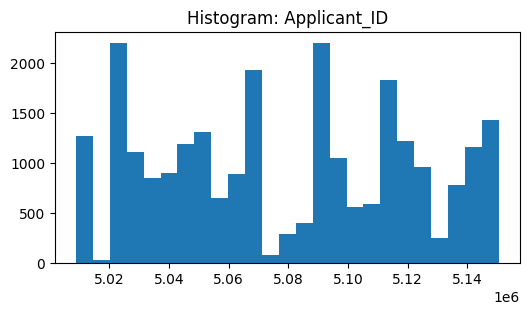

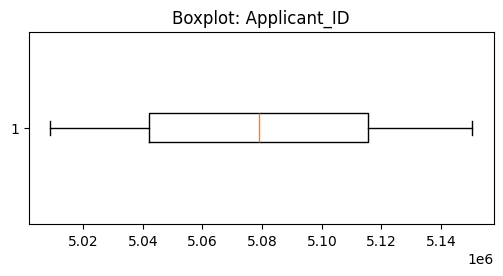

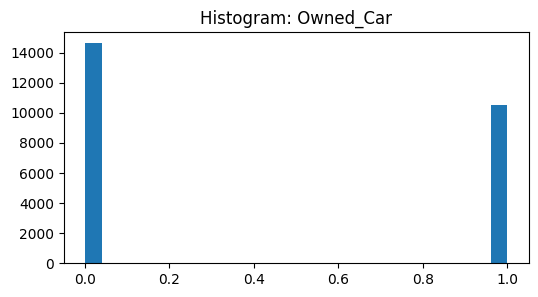

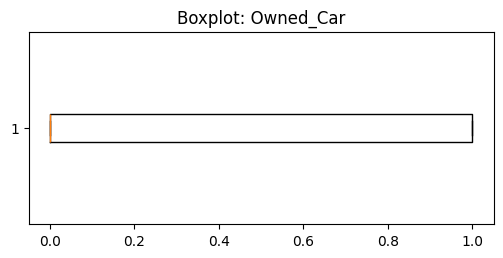

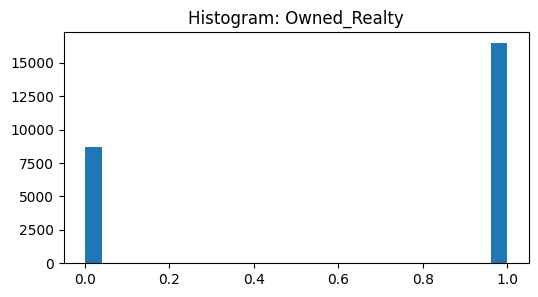

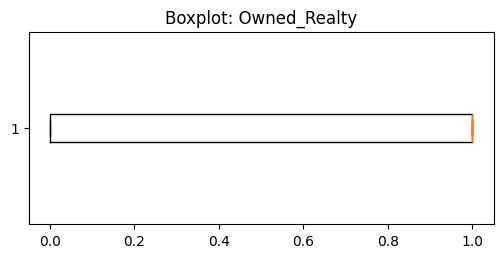

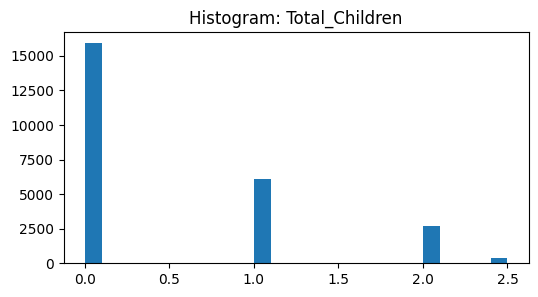

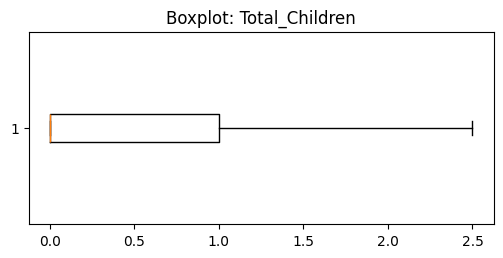

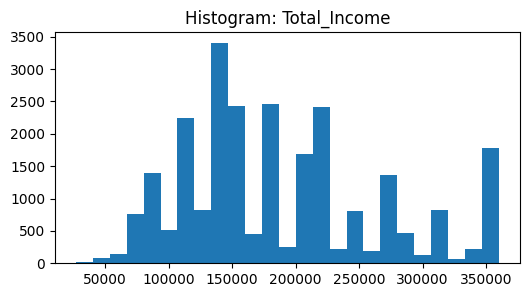

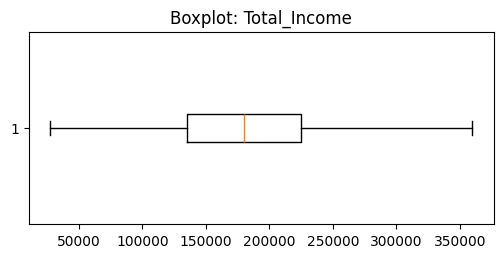

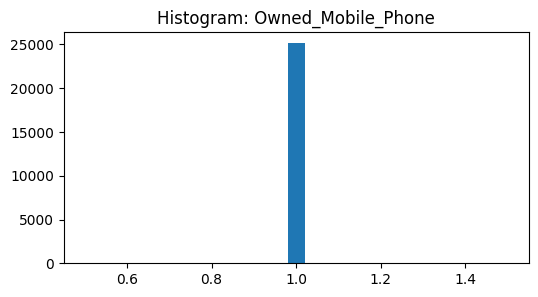

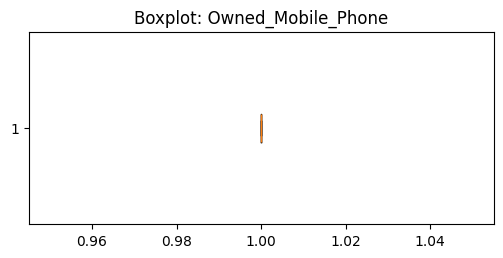

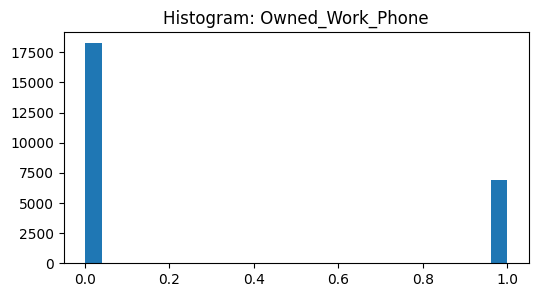

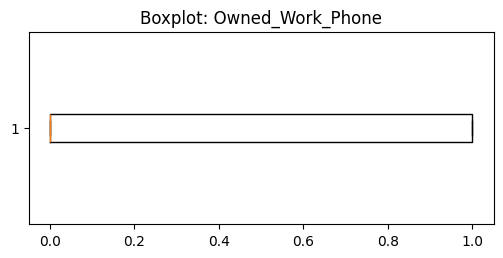

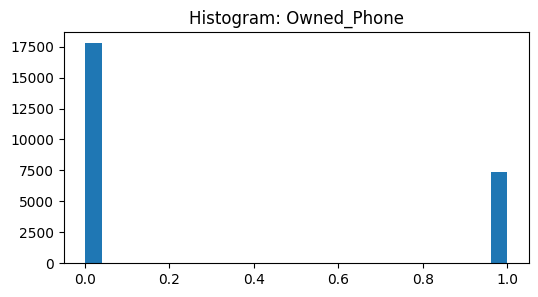

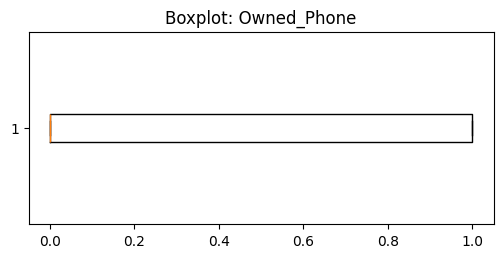

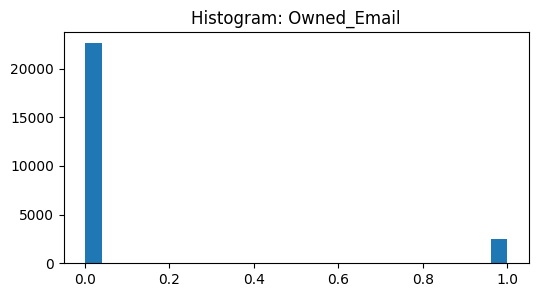

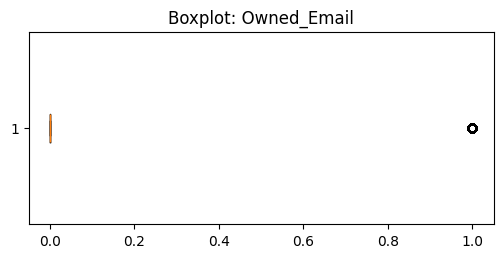

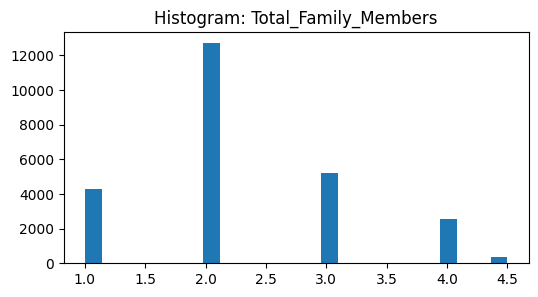

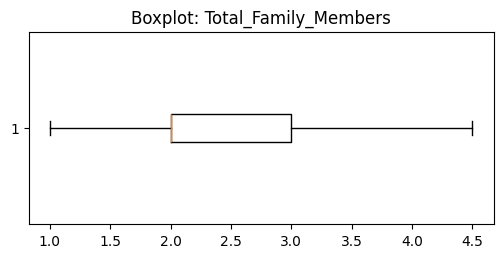

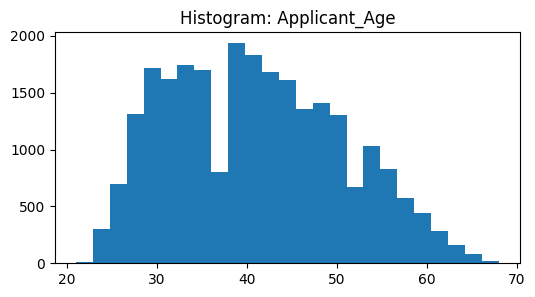

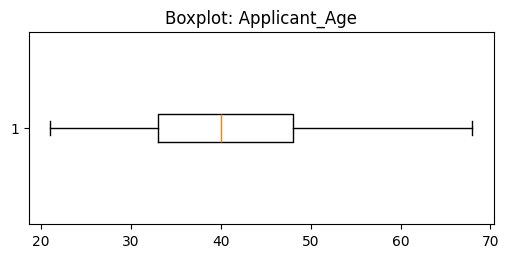

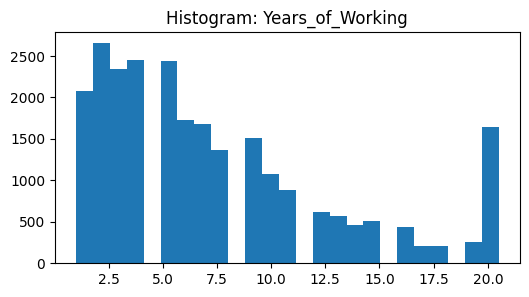

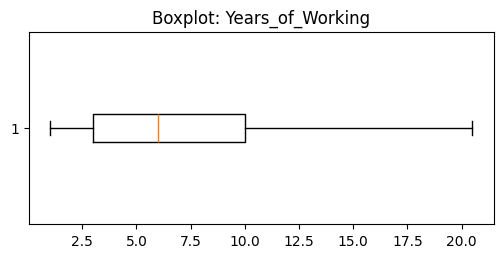

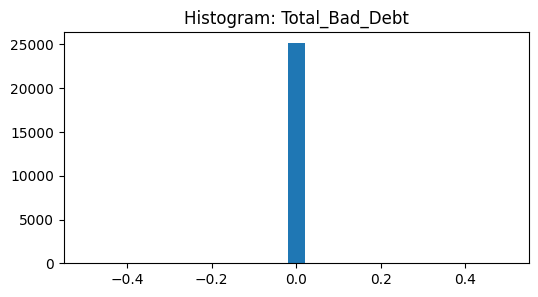

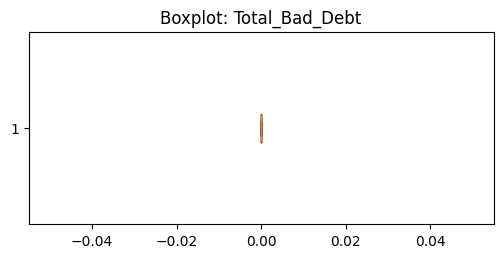

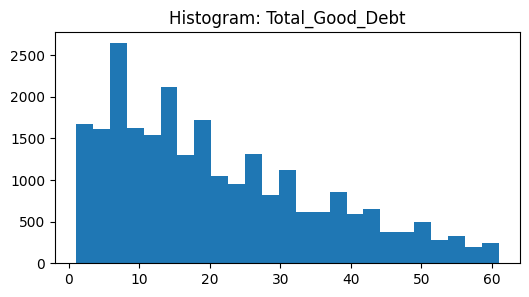

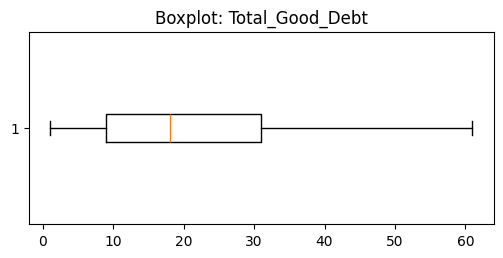

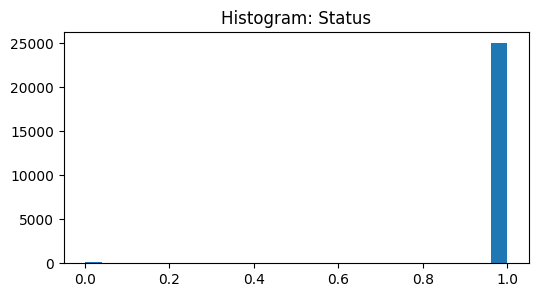

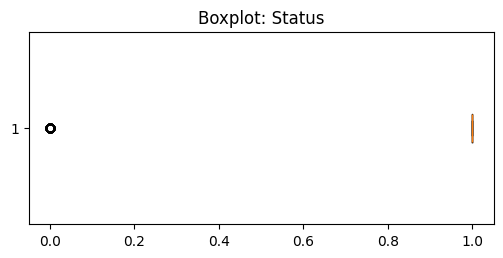

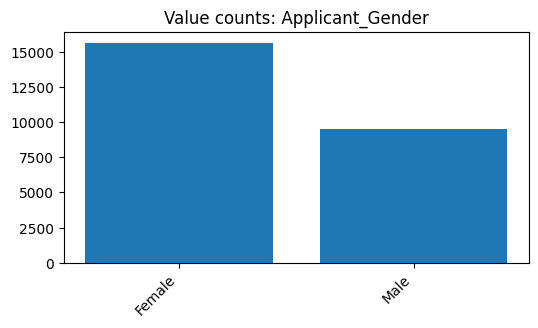

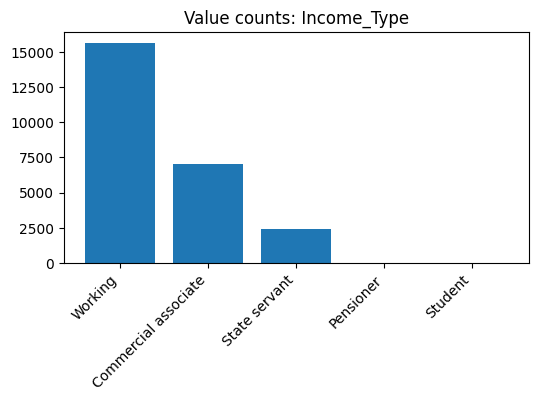

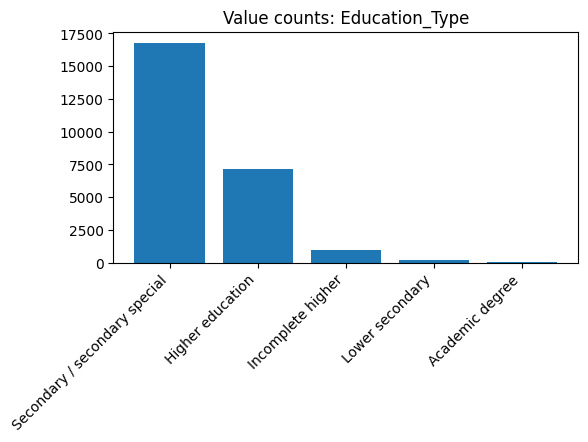

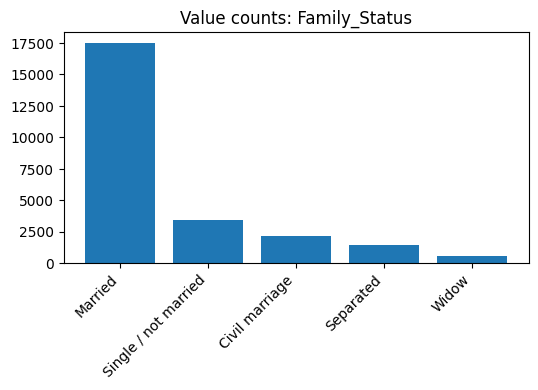

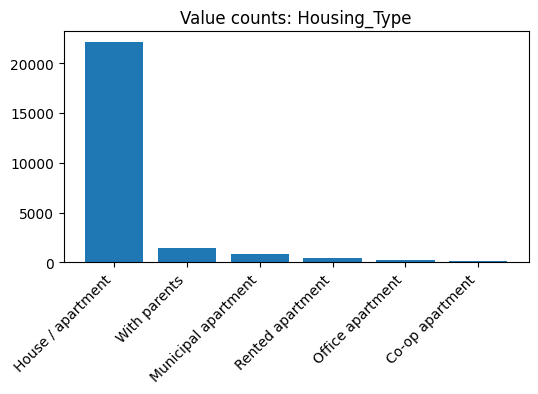

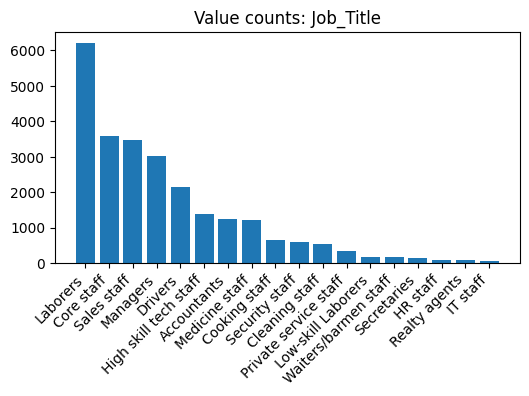

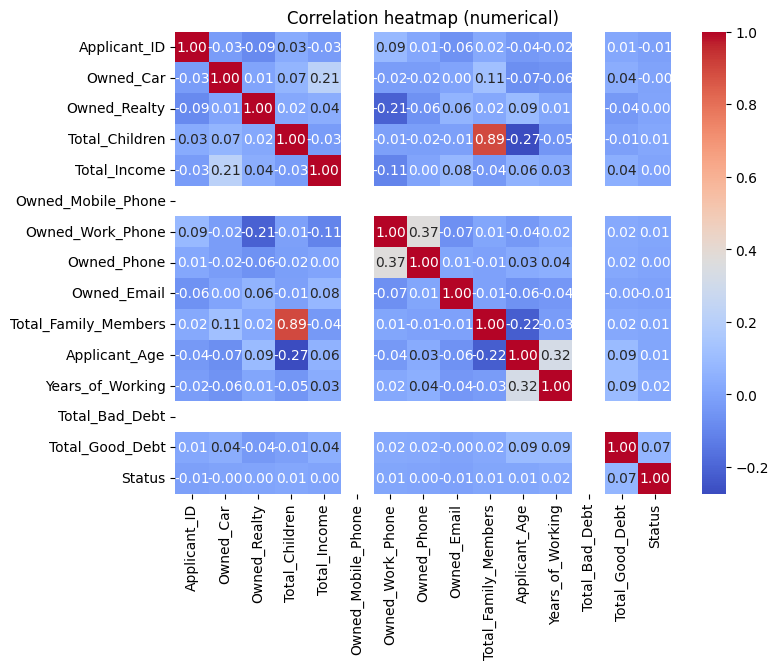

In [38]:
# Helper save
import os
# def save_plot(fig, name):
#     path = os.path.join("outputs/plots", name)
#     fig.savefig(path, bbox_inches='tight')
#     plt.close(fig)
#     print("saved:", path)

# Univariate: histograms & boxplots for numeric features
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
for c in num_cols:
    # fig, ax = 
    plt.subplots(figsize=(6,3))
    plt.hist(df_clean[c].dropna(), bins=25)
    plt.title(f"Histogram: {c}")
    # save_plot(fig, f"hist_{c}.png")

    # fig, ax = 
    plt.subplots(figsize=(6,2.5))
    plt.boxplot(df_clean[c].dropna(), vert=False)
    plt.title(f"Boxplot: {c}")
    # save_plot(fig, f"box_{c}.png")

# Categorical bar plots (top categories)
cat_cols = [c for c in df_clean.columns if df_clean[c].dtype == 'object' or df_clean[c].dtype.name == 'category']
for c in cat_cols:
    vc = df_clean[c].value_counts().nlargest(20)
    # fig, ax = plt.
    plt.subplots(figsize=(6,3))
    plt.bar(vc.index.astype(str), vc.values)
    plt.title(f"Value counts: {c}")
    plt.xticks(vc.index.astype(str), rotation=45, ha='right')
    # save_plot(fig, f"bar_{c}.png")

# Bivariate: approval rate by gender (if available)
if 'eligibility' in df_clean.columns and 'gender' in df_clean.columns:
    grp = df_clean.groupby('gender')['eligibility'].agg(['count','mean']).reset_index().rename(columns={'mean':'approval_rate'})
    # fig, ax = 
    plt.subplots(figsize=(5,3))
    plt.bar(grp['gender'], grp['approval_rate'])
    plt.ylim(0,1)
    plt.ylabel('Approval rate')
    plt.title('Approval Rate by Gender')
    # save_plot(fig, "approval_by_gender.png")

# Correlation heatmap (numerical)
if len(num_cols) >= 2:
    corr = df_clean[num_cols].corr()
    # fig, ax = 
    plt.subplots(figsize=(8,6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
    plt.title("Correlation heatmap (numerical)")
    plt.title("Correlation heatmap (numerical)")
    plt.show()
    # save_plot(fig, "correlation_heatmap.png")



C:\Users\abdul\AppData\Local\Temp\ipykernel_12172\1683676849.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=approved, x=col, order=order, palette='viridis')


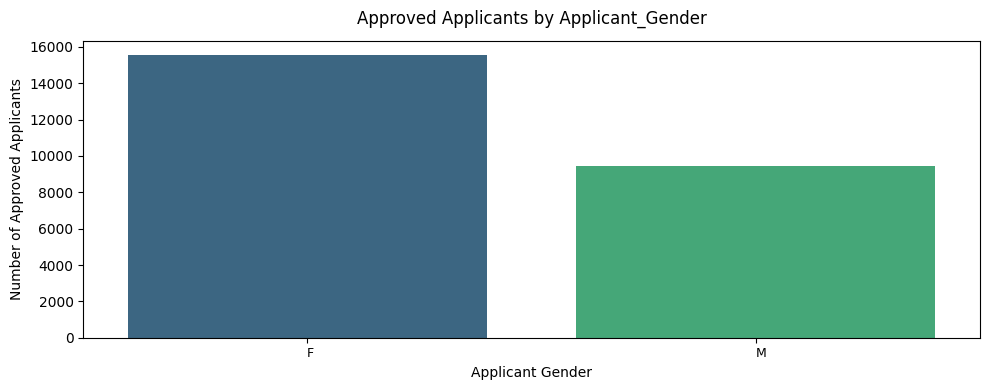

C:\Users\abdul\AppData\Local\Temp\ipykernel_12172\1683676849.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=approved, x=col, order=order, palette='viridis')


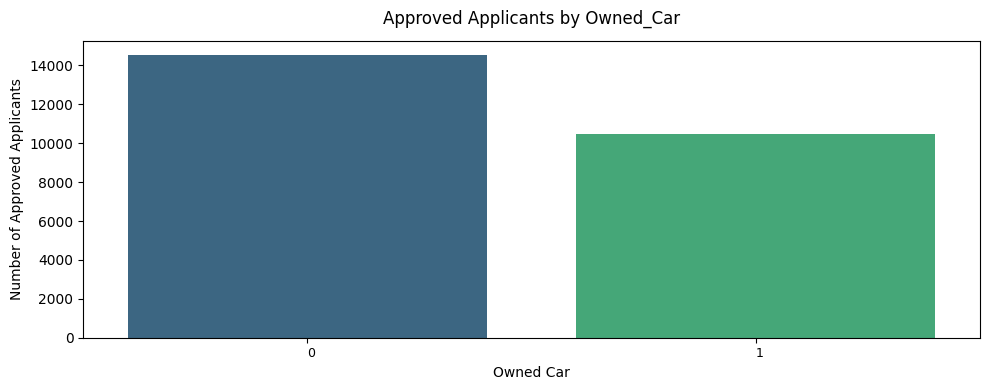

C:\Users\abdul\AppData\Local\Temp\ipykernel_12172\1683676849.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=approved, x=col, order=order, palette='viridis')


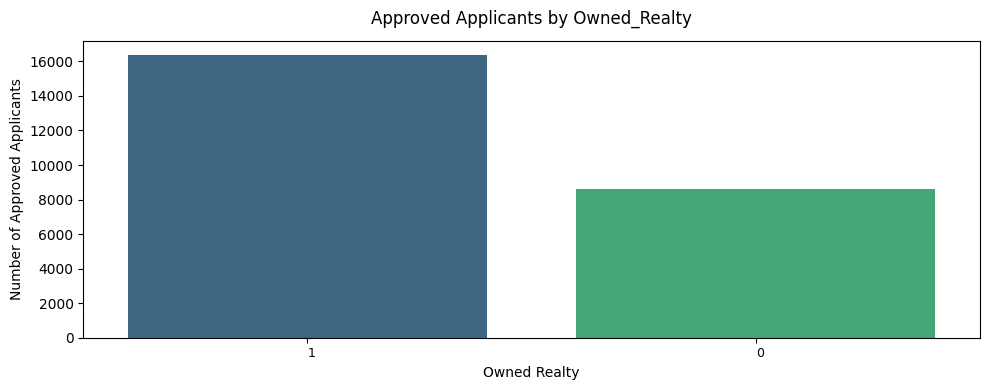

C:\Users\abdul\AppData\Local\Temp\ipykernel_12172\1683676849.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=approved, x=col, order=order, palette='viridis')


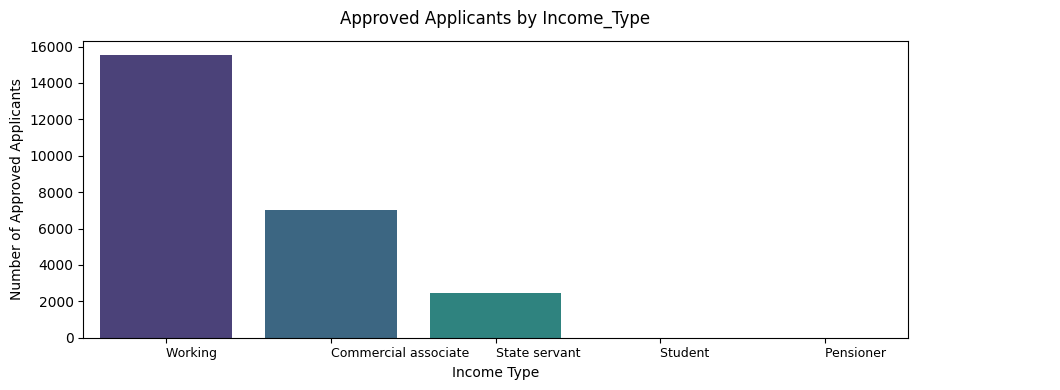

C:\Users\abdul\AppData\Local\Temp\ipykernel_12172\1683676849.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=approved, x=col, order=order, palette='viridis')


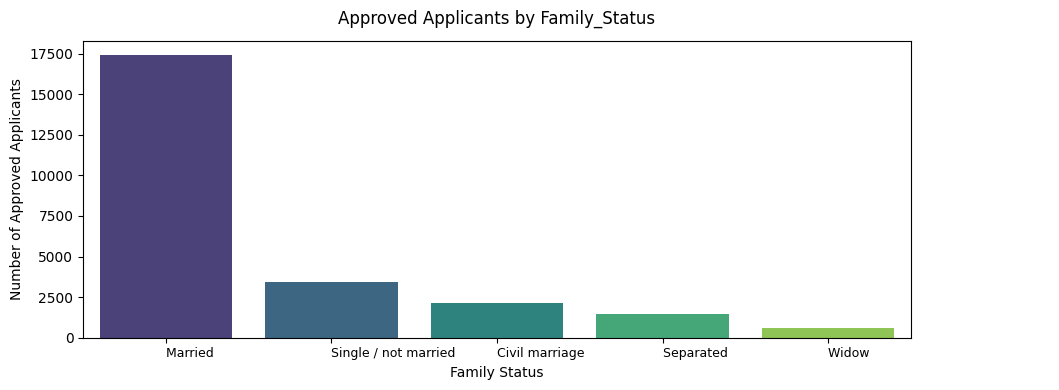

C:\Users\abdul\AppData\Local\Temp\ipykernel_12172\1683676849.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=approved, x=col, order=order, palette='viridis')


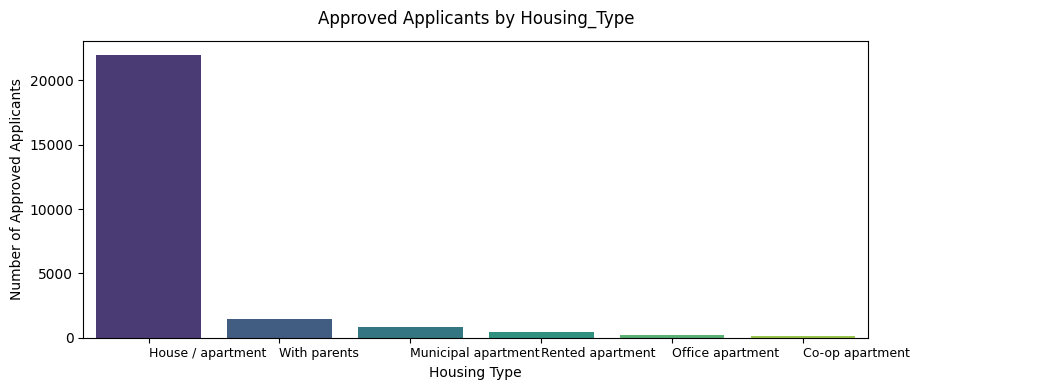

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt


# Filter only approved applicants
approved = df[df['Status'] == 1]

# List of categorical columns
cat_cols = [
    'Applicant_Gender', 'Owned_Car', 'Owned_Realty', 
    'Income_Type', 'Family_Status', 'Housing_Type'
]

# Loop through and plot
for col in cat_cols:
    plt.figure(figsize=(10,4))
    
    # Sort categories by frequency to keep bars in logical order
    order = approved[col].value_counts().index
    
    ax = sns.countplot(data=approved, x=col, order=order, palette='viridis')
    
    plt.title(f'Approved Applicants by {col}', fontsize=12, pad=12)
    plt.xlabel(col.replace('_', ' '), fontsize=10)
    plt.ylabel('Number of Approved Applicants', fontsize=10)
    
    # Rotate and align x-labels properly
    plt.xticks(ha='right', fontsize=9)
    
    # Adjust layout to avoid overlap
    plt.tight_layout()
    
    # Align tick labels with bars visually
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('left')
    
    # Save and show
    plt.show()


C:\Users\abdul\AppData\Local\Temp\ipykernel_12172\2951632536.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=approved, x=col, order=order, palette='viridis')


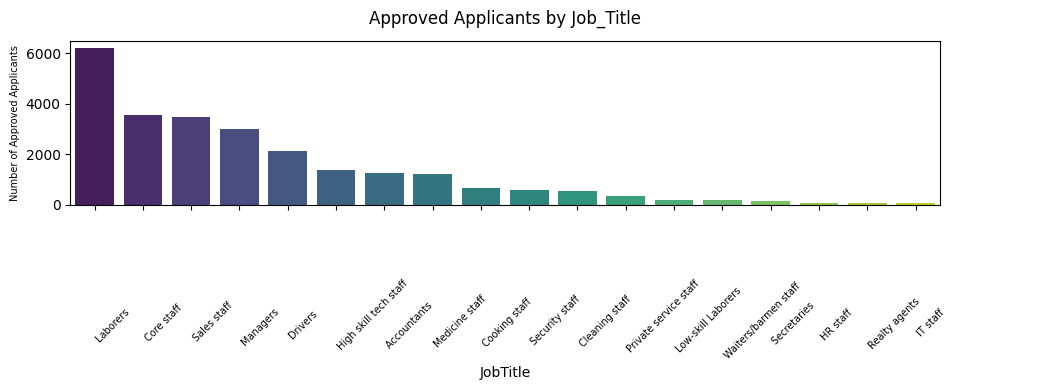

In [42]:
approved = df[df['Status'] == 1]
col='Job_Title'
plt.figure(figsize=(10,4))  
order = approved[col].value_counts().index
ax = sns.countplot(data=approved, x=col, order=order, palette='viridis')
plt.title(f'Approved Applicants by {col}', fontsize=12, pad=12)
plt.xlabel(col.replace('_', ''), fontsize=10)
plt.ylabel('Number of Approved Applicants', fontsize=7)
    
    # Rotate and align x-labels properly
plt.xticks(rotation=45, fontsize=7)
    
    # Adjust layout to avoid overlap
plt.tight_layout()
    
    # Align tick labels with bars visually
for label in ax.get_xticklabels():
    label.set_horizontalalignment('left')
    
    # Save and show
plt.show()

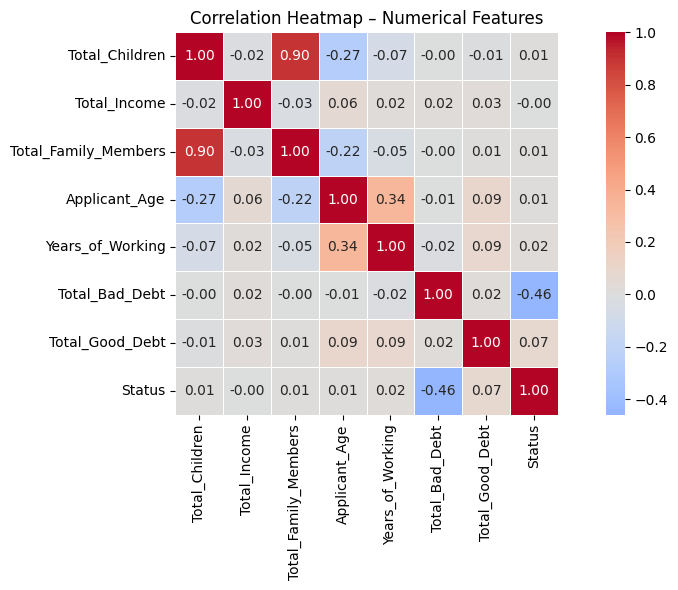

In [44]:
num_cols = [
    'Total_Children', 'Total_Income', 'Total_Family_Members',
    'Applicant_Age', 'Years_of_Working', 'Total_Bad_Debt',
    'Total_Good_Debt', 'Status'
]

# Compute correlation matrix
corr_matrix = df[num_cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Heatmap – Numerical Features")
plt.tight_layout()
plt.show()

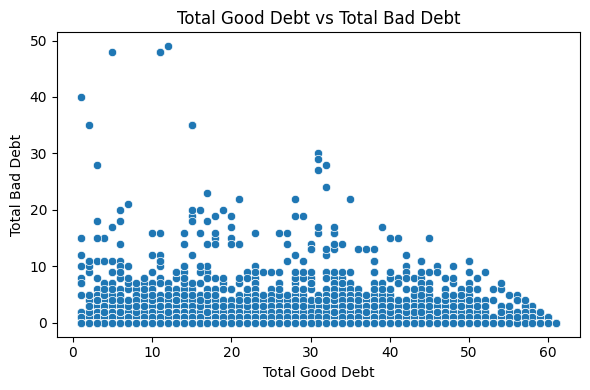

In [45]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='Total_Good_Debt', y='Total_Bad_Debt')

plt.title('Total Good Debt vs Total Bad Debt')
plt.xlabel('Total Good Debt')
plt.ylabel('Total Bad Debt')
plt.tight_layout()
plt.show()


In [46]:
corr = df[['Total_Good_Debt', 'Total_Bad_Debt']].corr().iloc[0,1]
print("Correlation:", round(corr, 3))


Correlation: 0.024


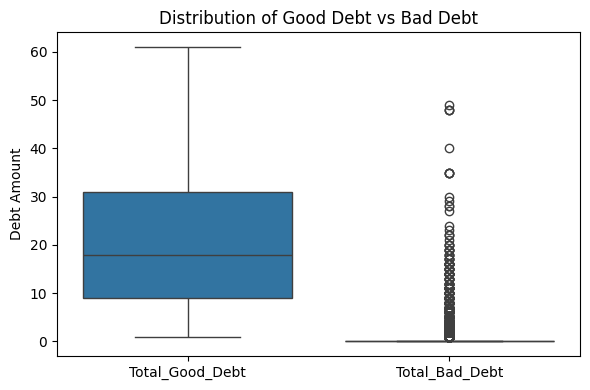

In [47]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df[['Total_Good_Debt', 'Total_Bad_Debt']])
plt.title('Distribution of Good Debt vs Bad Debt')
plt.ylabel('Debt Amount')
plt.tight_layout()
plt.show()


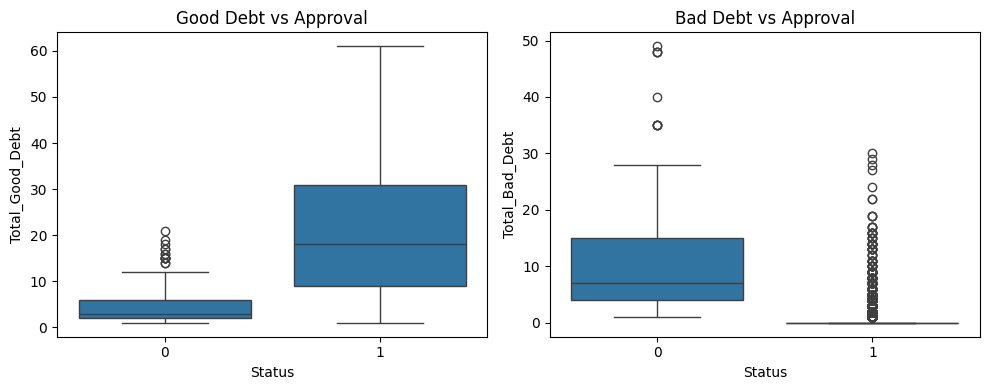

In [48]:
fig, ax = plt.subplots(1,2, figsize=(10,4))

sns.boxplot(x='Status', y='Total_Good_Debt', data=df, ax=ax[0])
ax[0].set_title('Good Debt vs Approval')

sns.boxplot(x='Status', y='Total_Bad_Debt', data=df, ax=ax[1])
ax[1].set_title('Bad Debt vs Approval')

plt.tight_layout()
plt.show()


In [49]:
target = "Status"

num_cols = [
    'Total_Children', 'Total_Income', 'Total_Family_Members',
    'Applicant_Age', 'Years_of_Working', 'Total_Bad_Debt', 
    'Total_Good_Debt'
]

cat_cols = [
    'Applicant_Gender', 'Owned_Car', 'Owned_Realty',
    'Income_Type', 'Education_Type', 'Family_Status',
    'Housing_Type', 'Owned_Mobile_Phone', 'Owned_Work_Phone',
    'Owned_Phone', 'Owned_Email', 'Job_Title'
]


# Numerical Feature Importance (t-test)

In [52]:
from scipy.stats import ttest_ind
import pandas as pd
import numpy as np

num_results = []

for col in num_cols:
    group1 = df[df[target] == 1][col].dropna()
    group0 = df[df[target] == 0][col].dropna()
    
    t_stat, p_val = ttest_ind(group1, group0, equal_var=False)
    
    num_results.append([col, "t-test", abs(t_stat), p_val])

num_df = pd.DataFrame(num_results, columns=["Feature", "Test", "Score", "P_Value"])
num_df["Significant"] = np.where(num_df["P_Value"] < 0.05, "Yes", "No")


In [51]:
pip install scipy


Note: you may need to restart the kernel to use updated packages.Collecting scipy
  Obtaining dependency information for scipy from https://files.pythonhosted.org/packages/f1/d0/22ec7036ba0b0a35bccb7f25ab407382ed34af0b111475eb301c16f8a2e5/scipy-1.16.3-cp311-cp311-win_amd64.whl.metadata
  Using cached scipy-1.16.3-cp311-cp311-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.16.3-cp311-cp311-win_amd64.whl (38.7 MB)




[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [53]:
from scipy.stats import chi2_contingency

cat_results = []

for col in cat_cols:
    contingency = pd.crosstab(df[col], df[target])
    chi2, p_val, dof, exp = chi2_contingency(contingency)
    
    cat_results.append([col, "Chi-square", chi2, p_val])

cat_df = pd.DataFrame(cat_results, columns=["Feature", "Test", "Score", "P_Value"])
cat_df["Significant"] = np.where(cat_df["P_Value"] < 0.05, "Yes", "No")


In [54]:
feature_importance = pd.concat([num_df, cat_df], ignore_index=True)

# Rank by Score (higher statistic = stronger influence)
feature_importance = feature_importance.sort_values(by="Score", ascending=False)
feature_importance


,Feature,Test,Score,P_Value,Significant
10,Income_Type,Chi-square,255.600577,4.045356e-54,Yes
18,Job_Title,Chi-square,104.600150,1.240569e-14,Yes
6,Total_Good_Debt,t-test,34.895130,4.136698e-68,Yes
13,Housing_Type,Chi-square,19.238191,1.735312e-03,Yes
5,Total_Bad_Debt,t-test,10.621937,5.540274e-19,Yes
7,Applicant_Gender,Chi-square,8.760120,3.078887e-03,Yes
12,Family_Status,Chi-square,6.682029,1.536763e-01,No
4,Years_of_Working,t-test,4.303309,3.417974e-05,Yes
0,Total_Children,t-test,2.286582,2.394431e-02,Yes
11,Education_Type,Chi-square,1.998728,7.359929e-01,No


In [56]:
pip install scikit-learn

  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/9f/71/34ddbd21f1da67c7a768146968b4d0220ee6831e4bcbad3e03dd3eae88b6/scikit_learn-1.7.2-cp311-cp311-win_amd64.whl.metadata
  Using cached scikit_learn-1.7.2-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Obtaining dependency information for joblib>=1.2.0 from https://files.pythonhosted.org/packages/1e/e8/685f47e0d754320684db4425a0967f7d3fa70126bffd76110b7009a0090f/joblib-1.5.2-py3-none-any.whl.metadata
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Obtaining dependency information for threadpoolctl>=3.1.0 from https://files.pythonhosted.org/packages/32/d5/f9a850d79b0851d1d4ef6456097579a9005b31fea68726a4ae5f2d82ddd9/threadpoolctl-3.6.0-py3-none-any.whl.metadata
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.7.2-cp311-cp311-win_amd64.whl (8.9 MB)
Using cached joblib-1.5.2-py3-none-any.whl (308 kB)
Using cached threadpoolctl-3.6.0


[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\abdul\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\abdul\AppData\Local\Temp\ipykernel_12172\2363120479.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance, x='Importance', y='Feature', palette='viridis')


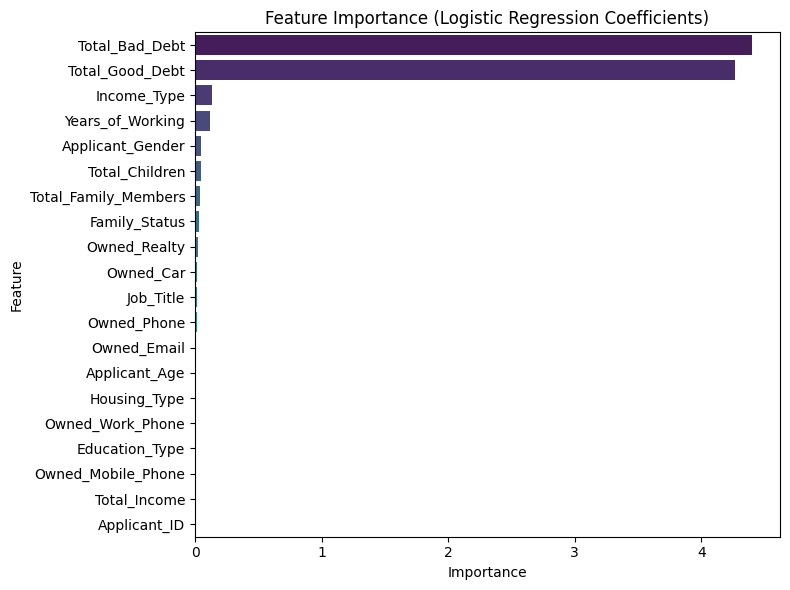

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

df_model = df.copy()

# Encode categorical variables
label_encoders = {}
for col in df_model.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le

# Features and target
X = df_model.drop('Status', axis=1)
y = df_model['Status']

# Logistic Regression Model
model = LogisticRegression(max_iter=200)
model.fit(X, y)

# Coefficients as feature importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': abs(model.coef_[0])
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8,6))
sns.barplot(data=importance, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.tight_layout()
plt.show()
